# DOES NOT WORK

# LATINO: LAtent consisTency INverse sOlver

**Algorithm 1 from LATINO-PRO**

```
for k = 1, ..., N do
    ε ~ N(0, I)
    z_{t_k} ← √α_{t_k} · E(x^{k-1}) + √(1-α_{t_k}) · ε     ▷ Encode + noise
    u^{k}   ← D(Gθ(z_{t_k}, t_k, c))                          ▷ Denoise + decode
    x^{k}   ← prox_{δ_k · g_y}(u^{k})                         ▷ Proximal step
end for
```

## 1. Install Dependencies

In [1]:
!pip install -q diffusers transformers accelerate deepinv huggingface_hub

## 2. Imports

In [2]:
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

from diffusers import (
    AutoencoderKL,
    DiffusionPipeline,
    UNet2DConditionModel,
    LCMScheduler,
)
from huggingface_hub import hf_hub_download
import deepinv as dinv
from torchvision.utils import save_image
from torchvision import transforms
from PIL import Image

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


PyTorch: 2.9.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Configuration

In [3]:
# ---- Experiment parameters ----
IMAGE_PATH   = "sample.png"
SCALE_FACTOR = 16                      # Updated to 16x as requested
N            = 8                       # N=8 is standard for LATINO
SIGMA_Y      = 0.01                    # Lower sigma for high-res reconstruction
PROMPT       = "a high quality photo"
OUTPUT_DIR   = "output"

# Auto-select device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Dimension must be divisible by scale_factor * 8
divisor = SCALE_FACTOR * 8
TARGET_SIZE = (1024 // divisor) * divisor
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Target size: {TARGET_SIZE}x{TARGET_SIZE}  (divisible by {divisor})")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

Using device: cuda
Target size: 1024x1024  (divisible by 128)


## 4. Define LATINO Components

In [17]:
# ============================================================
# Model Loading
# ============================================================

def load_pipeline(device="cuda"):
    """Load SDXL with DMD2 4-step UNet. Matches main_LATINO.py setup."""
    vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
    base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
    unet_config = UNet2DConditionModel.load_config(base_model_id, subfolder="unet")
    unet = UNet2DConditionModel.from_config(unet_config).to(device, torch.float16)
    unet.load_state_dict(torch.load(hf_hub_download("tianweiy/DMD2", "dmd2_sdxl_4step_unet_fp16.bin"), map_location=device, weights_only=True))

    pipe = DiffusionPipeline.from_pretrained(base_model_id, unet=unet, vae=vae, torch_dtype=torch.float16, variant="fp16").to(device)
    pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
    pipe.vae = pipe.vae.to(dtype=torch.float32) # Numerical stability fix
    return pipe

def vae_encode(vae, x, scaling_factor):
    x_norm = (2.0 * x - 1.0).to(dtype=torch.float32) # Operate in fp32
    return vae.encode(x_norm).latent_dist.mean * scaling_factor

def vae_decode(vae, z, scaling_factor):
    z_f32 = z.to(dtype=torch.float32)
    x = vae.decode(z_f32 / scaling_factor).sample
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)

def compute_psnr(pred, target):
    """Peak Signal-to-Noise Ratio (assumes [0, 1] range)."""
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float("inf")
    return (10 * torch.log10(1.0 / mse)).item()


def _get_x_init(y, target_size, device):
    """
    Implements the 'y_noise' initialization strategy.
    
    Args:
        y: Observation [B, C, H_low, W_low] in [0, 1] (or [-1, 1])
        target_size: Tuple (H, W)
    
    Returns:
        x_init: Upsampled image in [-1, 1] range
    """
    # 1. Normalize y to [-1, 1] if it isn't already (assuming input y is [0, 1])
    y_norm = (y * 2.0 - 1.0).clamp(-1, 1).to(device)

    # 2. Bicubic Upsample to target resolution
    # This acts as a 'warm start' compared to random noise or zero-filled adjoint
    x_init = F.interpolate(
        y_norm, 
        size=target_size, 
        mode="bicubic", 
        align_corners=False
    ).clamp(-1, 1)

    return x_init

# ============================================================
# Improved LATINO Logic
# ============================================================

def get_delta(t_k, df, scale_factor=16):
    """Refined adaptive delta based on scale factor 16 logic."""
    if scale_factor > 8:
        # return 1.5 * df / 10.0 if t_k > 300 else 3.0 * df / 10.0
        return 1.5 * df / 10.0 if t_k > 300 else 3.0 * df / 10.0
    return 3.0 * df / 10.0 if t_k > 300 else 2.0 * df / 10.0

def consistency_denoise(pipe, z_t, timestep, prompt_embeds, pooled_prompt_embeds, target_size):
    t = torch.tensor([timestep], device=z_t.device, dtype=torch.long)
    add_time_ids = torch.tensor([[target_size[0], target_size[1], 0, 0, target_size[0], target_size[1]]], device=z_t.device, dtype=z_t.dtype)
    added_cond_kwargs = {"text_embeds": pooled_prompt_embeds.to(dtype=z_t.dtype), "time_ids": add_time_ids}
    
    noise_pred = pipe.unet(z_t, t, encoder_hidden_states=prompt_embeds.to(dtype=z_t.dtype), added_cond_kwargs=added_cond_kwargs).sample
    alpha_t = pipe.scheduler.alphas_cumprod[timestep].to(device=z_t.device, dtype=z_t.dtype)
    return (z_t - torch.sqrt(1.0 - alpha_t) * noise_pred) / torch.sqrt(alpha_t)

@torch.no_grad()
def latino_updated(pipe, y, physics, prompt="a high quality photo", N=8,
                   sigma_y=0.01, scale_factor=16, device="cuda", verbose=True):
    """
    LATINO implementation aligned with main_LATINO.py and supporting 16x scale factor.
    """
    vae = pipe.vae
    s = vae.config.scaling_factor
    alphas_cumprod = pipe.scheduler.alphas_cumprod.to(device)
    
    # Use the specific custom timesteps from the main_LATINO.py script
    if N == 8:
        timesteps = torch.tensor([999, 874, 749, 624, 499, 374, 249, 124], 
                                 device=device, dtype=torch.long)
    else:
        # Fallback to linear spacing if N is not 8
        step = 1000 // N
        timesteps = torch.tensor([999 - i * step for i in range(N)], 
                                 device=device, dtype=torch.long)

    # Normalize measurements as done in the implementation pipeline
    y_norm = (y * 2 - 1).float()
    sigma_y_norm = sigma_y * 2 

    # Encode prompt (guidance_scale is usually 0 for LATINO/DMD2)
    prompt_embeds, _, pooled_prompt_embeds, _ = pipe.encode_prompt(
        prompt, device=device, num_images_per_prompt=1, do_classifier_free_guidance=False
    )

    B, C, H_low, W_low = y.shape
    H, W = H_low * scale_factor, W_low * scale_factor

    # Initialization: warm start with bicubic upsampling
    x = F.interpolate(y, size=(H, W), mode="bicubic", align_corners=False).clamp(0, 1)

    # Setup progress bar
    pbar = tqdm(timesteps, desc=f"LATINO ({scale_factor}x)") if verbose else timesteps

    for t_k in pbar:
        # 1. Encode image to latent space (using fp32 for stability)
        z = vae_encode(vae, x, s)
        
        # 2. Add noise according to the current timestep
        alpha_t = alphas_cumprod[t_k]
        noise = torch.randn_like(z)
        z_t = torch.sqrt(alpha_t) * z + torch.sqrt(1.0 - alpha_t) * noise

        # 3. Denoise with the DMD2 UNet
        z_0 = consistency_denoise(
            pipe, z_t.to(pipe.unet.dtype), t_k.item(), 
            prompt_embeds, pooled_prompt_embeds, (H, W)
        )

        # 4. Decode latent back to image space
        u = vae_decode(vae, z_0, s)
        u_norm = (u * 2 - 1).float()

        # 5. Data Consistency via Proximal Operator
        df = torch.norm(physics.A(u_norm) - y_norm).item()
        
        # Adjust delta based on scale factor 16 logic
        delta_k = get_delta(t_k.item(), df, scale_factor=scale_factor)

        # Apply stable gamma weighting to prevent high-frequency artifacts (dots)
        gamma = (delta_k * (1.0 - alpha_t.item())) / (sigma_y_norm**2 + 1e-6)
        gamma_stable = min(gamma * 0.1, 5.0) 

        prox_x_norm = physics.prox_l2(u_norm, y=y_norm, gamma=gamma_stable)
        x = ((prox_x_norm + 1) / 2).clamp(0.0, 1.0)

        if verbose:
            pbar.set_postfix(t=t_k.item(), gamma=f"{gamma_stable:.2f}", df=f"{df:.4f}")

    return x



@torch.no_grad()
def latino_y_noise(pipe, y, physics, prompt="a photo of a face", N=8,
                   sigma_y=0.01, scale_factor=16, device="cuda", verbose=True):
    # Setup
    vae = pipe.vae
    s = vae.config.scaling_factor
    alphas_cumprod = pipe.scheduler.alphas_cumprod.to(device)
    
    # 1. Define Timesteps (Exact 8-step schedule for DMD2)
    timesteps = torch.tensor([999, 874, 749, 624, 499, 374, 249, 124], 
                             device=device, dtype=torch.long)

    # 2. Prepare Measurement and Dimensions
    B, C, H_low, W_low = y.shape
    H, W = H_low * scale_factor, W_low * scale_factor
    y_norm = (y * 2 - 1).float() # [-1, 1]
    sigma_y_norm = sigma_y * 2 

    # 3. Encode Prompt
    prompt_embeds, _, pooled_prompt_embeds, _ = pipe.encode_prompt(
        prompt, device=device, num_images_per_prompt=1, do_classifier_free_guidance=False
    )

    # =========================================================
    # INIT STRATEGY: "y_noise" implementation
    # =========================================================
    
    # A. Get x_init (Bicubic Upsample in [-1, 1])
    x_init = _get_x_init(y, (H, W), device)
    
    # B. Encode to Latent Space (clean mu_z)
    z_clean = vae_encode(vae, (x_init + 1) / 2, s) # vae_encode expects [0, 1] input
    
    # C. Add Noise at t=999 (Initialize z_T)
    # This matches: latents = pipe.scheduler.add_noise(mu_z, noise, t=999)
    start_t = timesteps[0] # 999
    alpha_start = alphas_cumprod[start_t]
    noise = torch.randn_like(z_clean)
    
    # z_t starts as a noisy version of the bicubic upsample
    z_t = torch.sqrt(alpha_start) * z_clean + torch.sqrt(1.0 - alpha_start) * noise

    # Initial guess for the loop (used for the very first encoding if needed, 
    # but in LATINO loop we usually start from z_t directly)
    x = x_init 

    # =========================================================
    # MAIN LOOP
    # =========================================================
    pbar = tqdm(timesteps, desc=f"LATINO (y_noise)") if verbose else timesteps

    for i, t_k in enumerate(pbar):
        # 1. Denoise (Predict z_0 from z_t)
        # Note: We pass z_t directly. We do NOT re-add noise to z_t here 
        # because z_t is already the noisy latent from the previous step (or init).
        z_t_input = z_t.to(pipe.unet.dtype)
        
        z_0 = consistency_denoise(
            pipe, z_t_input, t_k.item(), 
            prompt_embeds, pooled_prompt_embeds, (H, W)
        )

        # 2. Decode to Image Space
        u = vae_decode(vae, z_0, s) # u is [0, 1]
        u_norm = (u * 2 - 1).float()

        # 3. Proximal Step (Data Consistency)
        df = torch.norm(physics.A(u_norm) - y_norm).item()
        
        # Adaptive Delta (Scale Factor 16 Logic)
        if scale_factor > 8:
            delta_k = 1.5 * df / 10.0 if t_k > 300 else 3.0 * df / 10.0
        else:
            delta_k = 3.0 * df / 10.0 if t_k > 300 else 2.0 * df / 10.0

        # Stable Gamma
        current_alpha = alphas_cumprod[t_k].item()
        gamma = (delta_k * (1.0 - current_alpha)) / (sigma_y_norm**2 + 1e-6)
        gamma_stable = min(gamma * 0.1, 5.0)

        prox_x_norm = physics.prox_l2(u_norm, y=y_norm, gamma=gamma_stable)
        x = ((prox_x_norm + 1) / 2).clamp(0.0, 1.0) # Cleaned x in [0, 1]

        # 4. Re-Encode and Re-Noise for next step (unless last step)
        if i < len(timesteps) - 1:
            next_t = timesteps[i + 1]
            z_clean_next = vae_encode(vae, x, s)
            
            # LATINO Logic: We need z_{t_{k+1}} for the next step.
            # We add noise corresponding to the NEXT timestep.
            alpha_next = alphas_cumprod[next_t]
            noise_new = torch.randn_like(z_clean_next)
            z_t = torch.sqrt(alpha_next) * z_clean_next + torch.sqrt(1.0 - alpha_next) * noise_new

        if verbose:
            pbar.set_postfix(t=t_k.item(), gamma=f"{gamma_stable:.2f}", df=f"{df:.4f}")

    return x


print("All components defined.")

All components defined.


## 5. Download / Load Image

In [5]:
# Option A: Download a sample CelebA-HQ face
# (uncomment these lines if you don't have a local image)

!pip install -q datasets
from datasets import load_dataset
ds = load_dataset("mattymchen/celeba-hq", split="train", streaming=True)
sample = next(iter(ds))
sample["image"].save("sample.png")
IMAGE_PATH = "sample.png"

# Option B: Upload your own image in Colab
# from google.colab import files
# uploaded = files.upload()
# IMAGE_PATH = list(uploaded.keys())[0]

# Load and prepare
# image = Image.open(IMAGE_PATH).convert("RGB")
image = sample["image"].convert("RGB")
transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.CenterCrop((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
])
gt = transform(image).unsqueeze(0).to(device)
print(f"Ground truth shape: {gt.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Ground truth shape: torch.Size([1, 3, 1024, 1024])


## 6. Create Degraded Observation

Observation y shape: torch.Size([1, 3, 64, 64])
Bicubic baseline PSNR: 19.14 dB


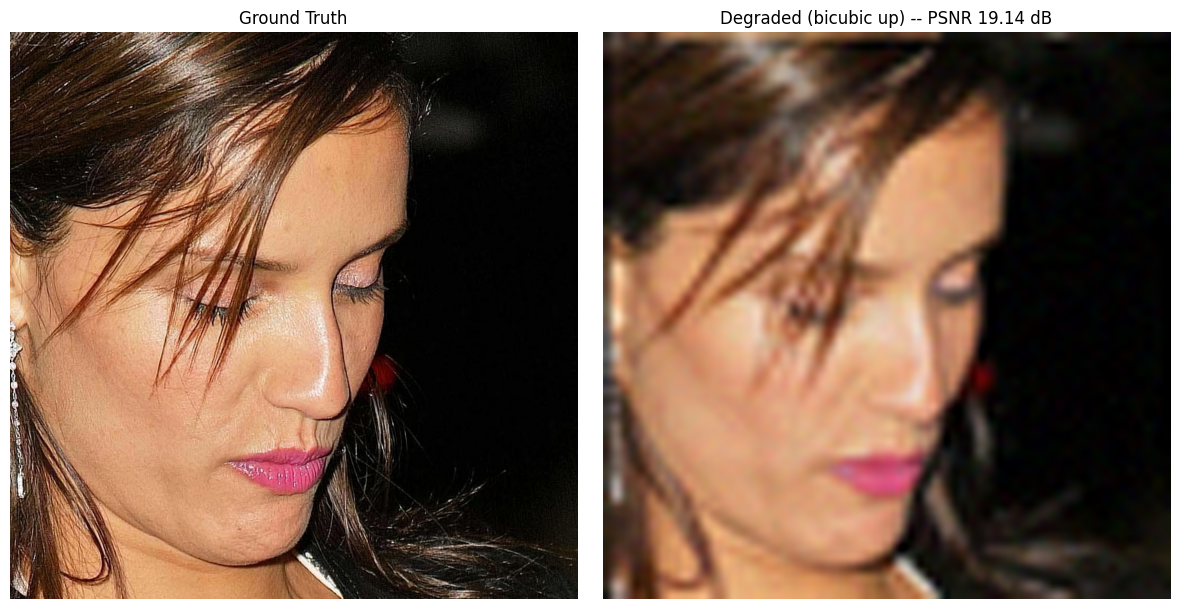

In [6]:
physics = dinv.physics.Downsampling(
    img_size=(3, TARGET_SIZE, TARGET_SIZE),
    factor=SCALE_FACTOR,
    filter="bicubic",
    device=device,
)

y = physics.A(gt)
if SIGMA_Y > 0:
    y = y + SIGMA_Y * torch.randn_like(y)
    y = y.clamp(0.0, 1.0)

print(f"Observation y shape: {y.shape}")

# Bicubic baseline
y_up = F.interpolate(y, size=(TARGET_SIZE, TARGET_SIZE),
                     mode="bicubic", align_corners=False).clamp(0, 1)
baseline_psnr = compute_psnr(y_up, gt)
print(f"Bicubic baseline PSNR: {baseline_psnr:.2f} dB")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gt[0].cpu().permute(1, 2, 0))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(y_up[0].cpu().permute(1, 2, 0))
axes[1].set_title(f"Degraded (bicubic up) -- PSNR {baseline_psnr:.2f} dB")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 7. Load SDXL + DMD2 Pipeline

In [7]:
pipe = load_pipeline(device=device)
physics = dinv.physics.Downsampling(img_size=(3, TARGET_SIZE, TARGET_SIZE), factor=SCALE_FACTOR, filter="bicubic", device=device)
print("Pipeline loaded.")
print(f"  Scheduler: {pipe.scheduler.__class__.__name__}")
print(f"  Prediction type: {pipe.scheduler.config.prediction_type}")
print(f"  VAE dtype: {pipe.vae.dtype}")
print(f"  UNet dtype: {pipe.unet.dtype}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The config attributes {'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


Pipeline loaded.
  Scheduler: LCMScheduler
  Prediction type: epsilon
  VAE dtype: torch.float32
  UNet dtype: torch.float16


## 8. Run LATINO

In [14]:
N = 8
result = latino_updated(
    pipe, y, physics,
    prompt=PROMPT,
    N=N,
    sigma_y=SIGMA_Y,
    scale_factor=SCALE_FACTOR,
    device=device,
    verbose=True,
)

latino_psnr = compute_psnr(result, gt)
print(f"\nLATINO PSNR: {latino_psnr:.2f} dB  (baseline: {baseline_psnr:.2f} dB)")

LATINO (16x): 100%|██████████| 8/8 [00:37<00:00,  4.67s/it, df=66.1854, gamma=5.00, t=124]


LATINO PSNR: 9.75 dB  (baseline: 19.14 dB)


In [20]:
# Updated Call
result = latino_y_noise(
    pipe, y, physics,
    prompt="high quality photo",
    N=8,
    sigma_y=SIGMA_Y,
    scale_factor=SCALE_FACTOR,
    device=device,
    verbose=True,
)

latino_psnr = compute_psnr(result, gt)
print(f"\nLATINO PSNR: {latino_psnr:.2f} dB")

LATINO (y_noise): 100%|██████████| 8/8 [00:33<00:00,  4.22s/it, df=63.5050, gamma=5.00, t=124]


LATINO PSNR: 10.39 dB


## 9. Visualise Results

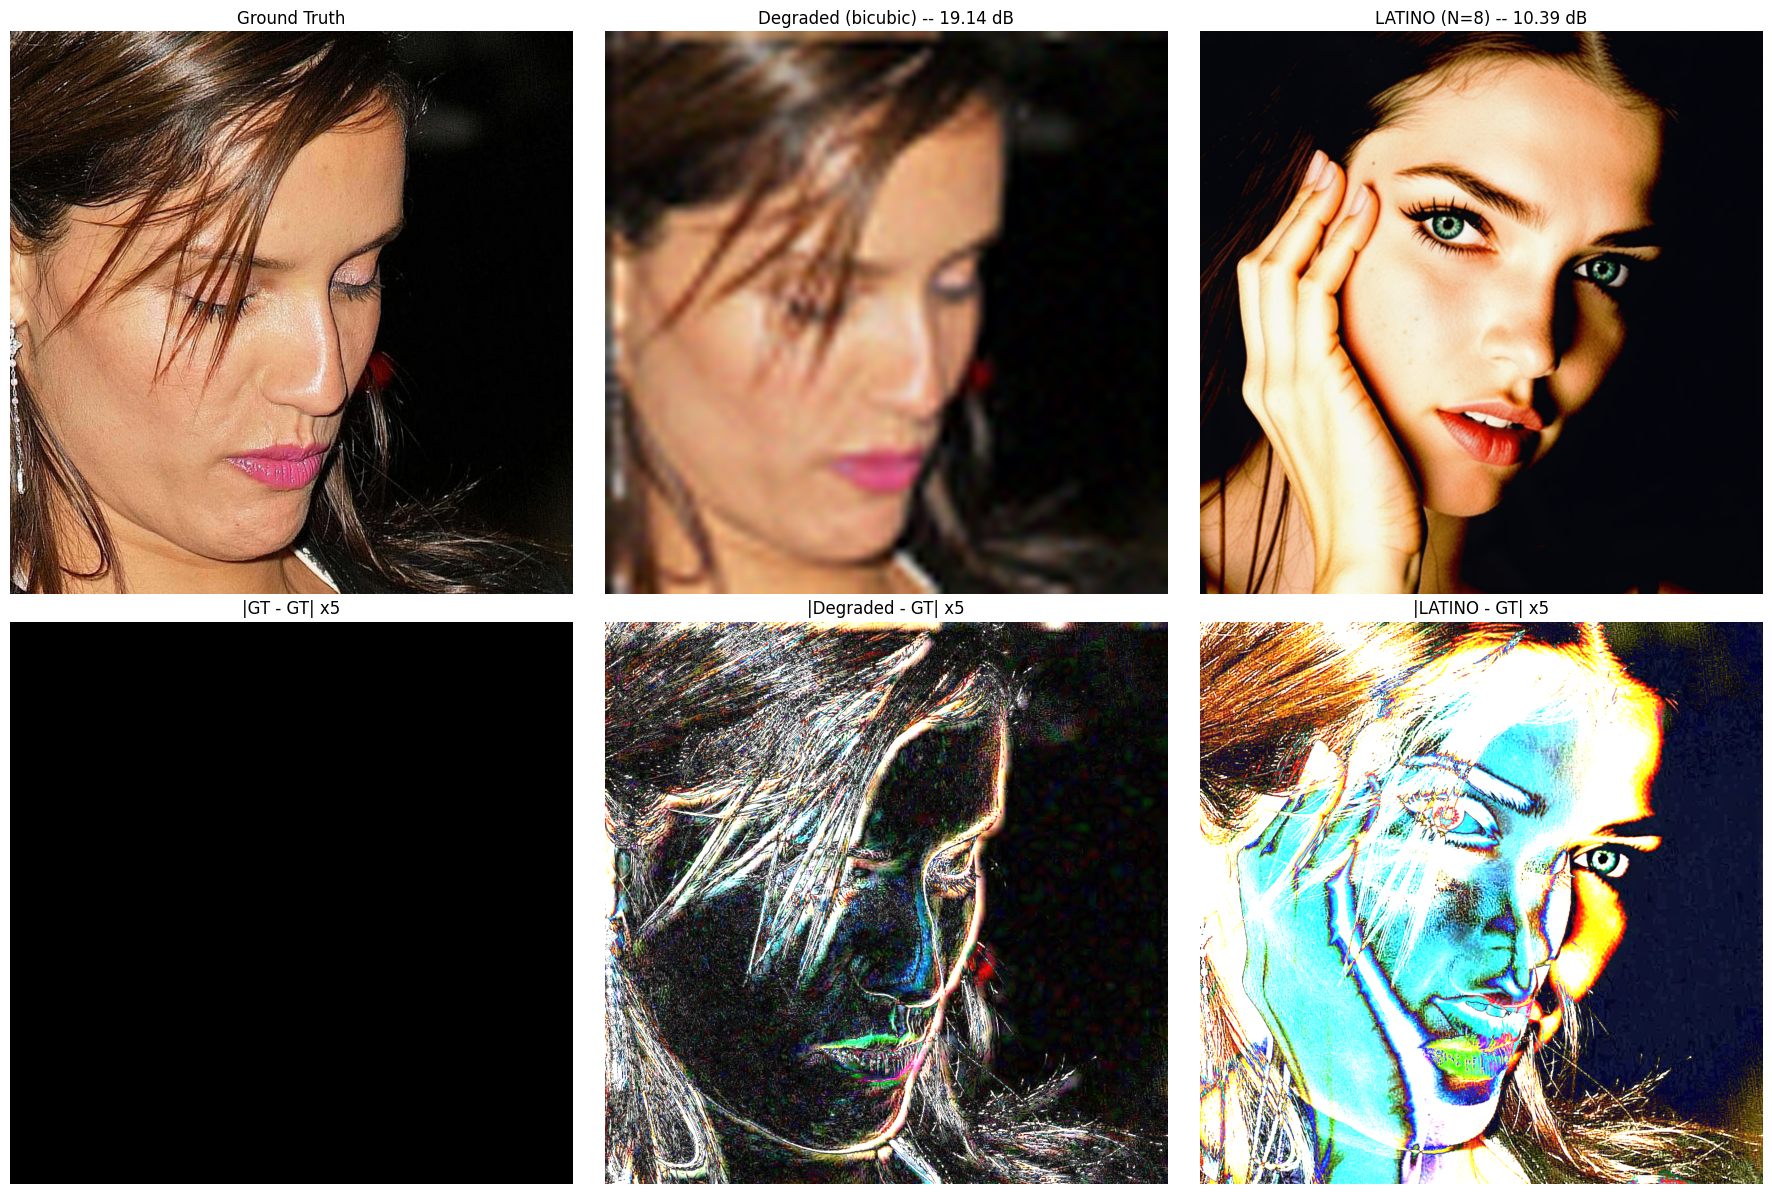

Saved comparison to output/comparison.png


In [21]:
gt_img = gt[0].cpu().permute(1, 2, 0)
yup_img = y_up[0].cpu().permute(1, 2, 0).clamp(0, 1)
res_img = result[0].cpu().permute(1, 2, 0).clamp(0, 1)

# Absolute error maps (amplified for visibility)
amp = 5
diff_gt = (gt_img - gt_img).abs() * amp          # zero (reference)
diff_yup = (yup_img - gt_img).abs() * amp
diff_res = (res_img - gt_img).abs() * amp

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: images
axes[0, 0].imshow(gt_img)
axes[0, 0].set_title("Ground Truth")
axes[0, 0].axis("off")

axes[0, 1].imshow(yup_img)
axes[0, 1].set_title(f"Degraded (bicubic) -- {baseline_psnr:.2f} dB")
axes[0, 1].axis("off")

axes[0, 2].imshow(res_img)
axes[0, 2].set_title(f"LATINO (N={N}) -- {latino_psnr:.2f} dB")
axes[0, 2].axis("off")

# Row 2: |image - GT| x amp
axes[1, 0].imshow(diff_gt.clamp(0, 1))
axes[1, 0].set_title(f"|GT - GT| x{amp}")
axes[1, 0].axis("off")

axes[1, 1].imshow(diff_yup.clamp(0, 1))
axes[1, 1].set_title(f"|Degraded - GT| x{amp}")
axes[1, 1].axis("off")

axes[1, 2].imshow(diff_res.clamp(0, 1))
axes[1, 2].set_title(f"|LATINO - GT| x{amp}")
axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved comparison to {OUTPUT_DIR}/comparison.png")

## 10. Save Outputs

In [16]:
out = Path(OUTPUT_DIR)
save_image(gt, out / "ground_truth.png")
save_image(y_up.clamp(0, 1), out / "degraded_bicubic.png")
save_image(result.clamp(0, 1), out / "latino_result.png")
print(f"Images saved to {out}/")

Images saved to output/
